# Notebook support pour projet ML modèle supervisé (Classification)
## NoteBook 3 - 1ère Modélisation

Pour introduire cette phase de modélisation, il est important de clarifier l’objectif prioritaire des modèles que nous allons développer.

D’un point de vue métier, l’enjeu principal est de limiter les faux négatifs, c’est-à-dire les salariés réellement à risque de départ que le modèle ne détecte pas.  
En effet, un départ non anticipé peut engendrer des coûts significatifs pour l’entreprise : recrutement, intégration, perte de productivité, perte de connaissances métier et désorganisation des équipes.

Dans ce contexte, le rappel (`Recall`) sur la classe positive nous apparaît comme la métrique à privilégier pour orienter la sélection et l’optimisation des modèles.


Commençons par charger les données de sorties de la phase de Feature Engineering. 

In [7]:
import numpy as np
import pandas as pd
from pathlib import Path
import importlib
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

#import des données : 
df_MODEL = pd.read_csv("../data/processed/df_MODEL.csv")
df_MODEL.shape

(1470, 61)

In [9]:
print("a_quitte_l_entreprise" in df_MODEL.columns)
print(df_MODEL.columns.tolist())

True
['id_employee', 'age', 'genre', 'revenu_mensuel', 'nombre_experiences_precedentes', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente', 'a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'distance_domicile_travail', 'niveau_education', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel', 'revenu_mensuel_log', 'annee_experience_totale_log', 'annees_dans_l_entreprise_log', 'annees_dans_le_poste_actuel_log', 'annees_depuis_la_derniere_promotion_log', 'annes_sous_responsable_actuel_log', 'distance_domicile_travail_classe', 'ratio_anciennete_poste', 'ratio_anciennete_manager', 'ratio_experience_entreprise', '

## Séparation jeu de données en : Train/Test (90%) pour CV + Test final (10%)

In [10]:
#séparation des variables explicatives et de la cible
target = "a_quitte_l_entreprise"
X = df_MODEL.drop(columns=[target])
y = df_MODEL[target]

# Split : 90 % train (pour CV) / 10 % test final
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.10,random_state=42)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1323, 60)
X_test  : (147, 60)
y_train : (1323,)
y_test  : (147,)


## Tests premiers modèles


Dummy
Train | Accuracy: 0.8382 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000 | ROC AUC: 0.5000
Test  | Accuracy: 0.8382 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000 | ROC AUC: 0.5000


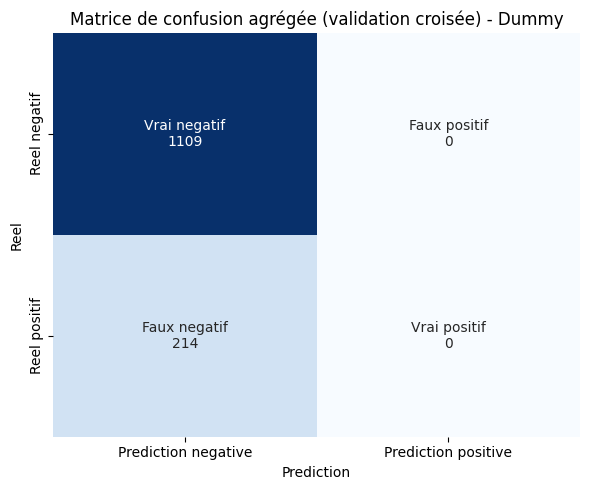


Logistic Regression
Train | Accuracy: 0.9042 | Precision: 0.8144 | Recall: 0.5277 | F1: 0.6402 | ROC AUC: 0.8873
Test  | Accuracy: 0.8897 | Precision: 0.7680 | Recall: 0.4697 | F1: 0.5767 | ROC AUC: 0.8416


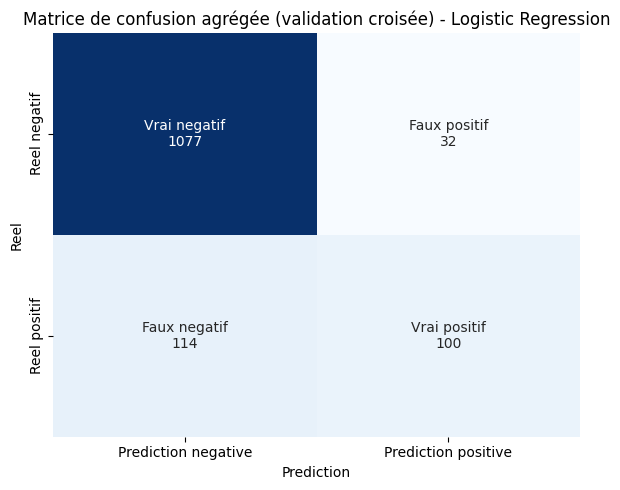


Random Forest
Train | Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000 | ROC AUC: 1.0000
Test  | Accuracy: 0.8541 | Precision: 0.7464 | Recall: 0.1541 | F1: 0.2538 | ROC AUC: 0.7928


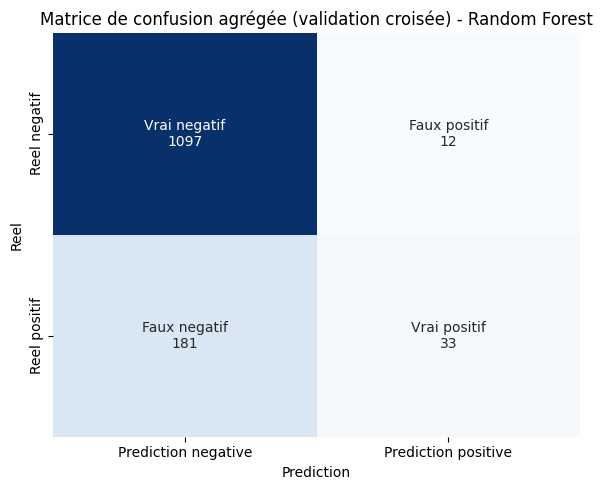

In [21]:
import importlib
import src.Fonctions_MODEL as Fonctions_MODEL
importlib.reload(Fonctions_MODEL)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "Dummy": DummyClassifier(strategy="most_frequent", random_state=42),
    "Logistic Regression": Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(max_iter=3000, random_state=42)),]),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

for name, model in models.items():
    Fonctions_MODEL.evaluate_classification_model_cv(model=model,X=X_train,y=y_train,cv=5,stratify=False,model_name=name,)


## Premiers résultats de modélisation

### Dummy
Le modèle Dummy confirme qu’une accuracy élevée ne suffit pas à juger la performance dans un contexte de cible déséquilibrée.  
En prédisant systématiquement la classe majoritaire, il atteint environ 84 % d’accuracy, mais son rappel, sa précision et son score F1 sont nuls.  
Il ne détecte donc aucun départ et ne présente aucun intérêt opérationnel.

### Logistic Regression
La régression logistique constitue ici la baseline la plus équilibrée.  
Elle améliore nettement l’ensemble des métriques par rapport au Dummy, avec un bon pouvoir discriminant global (`ROC AUC = 0,8416` sur le jeu de test).  
Surtout, elle détecte une part significative des départs (`Recall = 0,4697`), ce qui est cohérent avec l’objectif métier prioritaire.  
Même si ce rappel reste perfectible, le modèle linéaire offre à ce stade le meilleur compromis entre détection des départs et stabilité de généralisation.

### Random Forest
Le Random Forest montre un surapprentissage assez marqué : les scores sont parfaits sur les folds d’entraînement, mais se dégradent nettement sur les folds de test.  
En particulier, son rappel chute à `0,1541`, ce qui signifie qu’il manque la grande majorité des départs.  
Malgré une précision correcte, ce modèle est à ce stade moins pertinent que la régression logistique, car il répond mal à l’enjeu métier principal, qui est de limiter les faux négatifs.

En l’état, **la régression logistique apparaît donc comme le meilleur premier modèle de référence**.  
Le prochain enjeu sera d’améliorer encore le rappel sur la classe positive, soit en ajustant le seuil de décision, soit en testant des modèles ou réglages mieux adaptés au déséquilibre de classes.
